# 🚀 Practice Day 06

**📅 Date:** 2026-09-18  
**📁 Category:** Phase 2 · SQL 기초 - DuckDB (Round 1/5)

---
# 🎯 Today's Goal
*What am I trying to solve today?*

- Write SQL queries directly against a pandas DataFrame using DuckDB (duckdb.sql()) (DuckDB로 pandas DataFrame에 SQL 쿼리 직접 실행)
- Practice SELECT, WHERE, ORDER BY, and GROUP BY syntax (SELECT, WHERE, ORDER BY, GROUP BY 문법 연습)
- Compare how the same question reads in SQL vs. the Pandas syntax you already know (같은 질문을 SQL로 풀 때 Pandas와 어떻게 다른지 비교)

---
# 📂 Dataset

**Dataset Name:** Online Course Enrollment Data (온라인 강의 수강 데이터)

**Source:** Synthetically generated for practice, fixed random seed (연습용으로 코드에서 직접 생성, seed 고정)

**Description:** 270 enrollment records across 15 courses in 5 categories (Programming, Data, Design, Marketing, Language). Includes enrollment date, price, completion status, and rating (only present for completed courses).
(15개 강의 x 5개 카테고리(Programming/Data/Design/Marketing/Language)에 걸친 수강 기록 270건. 수강일, 가격, 완료 상태, 평점(완료된 강의에만 존재) 포함)

## Dataset Preview

In [54]:
# Dataset Preview
import pandas as pd
import numpy as np

np.random.seed(42)

course_info = {
    'Python for Beginners': ('Programming', 89000),
    'JavaScript Fundamentals': ('Programming', 69000),
    'Web Development Bootcamp': ('Programming', 129000),
    'SQL Fundamentals': ('Data', 79000),
    'Data Analysis with Pandas': ('Data', 99000),
    'Introduction to Statistics': ('Data', 59000),
    'UI/UX Design Basics': ('Design', 89000),
    'Figma for Beginners': ('Design', 49000),
    'Graphic Design Fundamentals': ('Design', 69000),
    'Digital Marketing 101': ('Marketing', 59000),
    'Social Media Marketing': ('Marketing', 49000),
    'SEO Fundamentals': ('Marketing', 39000),
    'Business English': ('Language', 99000),
    'Korean for Foreigners': ('Language', 79000),
    'Japanese Conversation': ('Language', 89000),
}
course_names = list(course_info.keys())
n_enrollments = 270

# some courses are more popular than others
popularity = np.random.dirichlet(np.ones(len(course_names)) * 2)
chosen_courses = np.random.choice(course_names, size=n_enrollments, p=popularity)

category = [course_info[c][0] for c in chosen_courses]
price = [course_info[c][1] for c in chosen_courses]
enrollment_date = np.random.choice(pd.date_range('2025-10-01', '2026-07-15', freq='D'), size=n_enrollments)
completion_status = np.random.choice(['Completed', 'In Progress', 'Not Started'], size=n_enrollments, p=[0.40, 0.35, 0.25])
rating = [np.random.choice([3, 4, 5], p=[0.15, 0.40, 0.45]) if s == 'Completed' else None for s in completion_status]

df = pd.DataFrame({
    'enrollment_id': [f'ENR-{i+1:05d}' for i in range(n_enrollments)],
    'course_name': chosen_courses,
    'category': category,
    'price': price,
    'enrollment_date': pd.to_datetime(enrollment_date),
    'completion_status': completion_status,
    'rating': rating,
})

df.head()

,enrollment_id,course_name,category,price,enrollment_date,completion_status,rating
0,ENR-00001,Web Development Bootcamp,Programming,129000,2025-11-16,Not Started,NaN
1,ENR-00002,Python for Beginners,Programming,89000,2026-02-21,Not Started,NaN
2,ENR-00003,Korean for Foreigners,Language,79000,2026-06-26,Completed,5.0
3,ENR-00004,Japanese Conversation,Language,89000,2026-02-01,In Progress,NaN
4,ENR-00005,Business English,Language,99000,2026-01-14,Completed,5.0


## Dataset Information

In [55]:
# Dataset Information
import duckdb

print(df.shape)

# This is a SQL-focused file: DuckDB can query a pandas DataFrame directly by
# variable name in the FROM clause, no separate database setup needed. Example:
duckdb.sql("SELECT COUNT(*) AS total_enrollments FROM df").show()

df.info()
df.describe()

(270, 7)
┌───────────────────┐
│ total_enrollments │
│       int64       │
├───────────────────┤
│               270 │
└───────────────────┘

<class 'pandas.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   enrollment_id      270 non-null    str           
 1   course_name        270 non-null    str           
 2   category           270 non-null    str           
 3   price              270 non-null    int64         
 4   enrollment_date    270 non-null    datetime64[us]
 5   completion_status  270 non-null    str           
 6   rating             118 non-null    float64       
dtypes: datetime64[us](1), float64(1), int64(1), str(4)
memory usage: 14.9 KB


,price,enrollment_date,rating
count,270.000000,270,118.000000
mean,81888.888889,2026-02-26 18:45:20,4.220339
min,39000.000000,2025-10-01 00:00:00,3.000000
25%,69000.000000,2025-12-23 12:00:00,4.000000
50%,89000.000000,2026-02-28 00:00:00,4.000000
75%,99000.000000,2026-05-08 18:00:00,5.000000
max,129000.000000,2026-07-13 00:00:00,5.000000
std,21843.194704,NaN,0.717731


---
# ❓ Business Questions

1. Which enrollments are in the 'Data' category with a price of 80,000 KRW or more? (Data 카테고리이면서 가격이 8만원 이상인 수강은?)
2. What are the top 10 highest-rated completed enrollments? (평점이 가장 높은 완료 수강 상위 10개는?)
3. What is the enrollment count and average rating for each category? (카테고리별 수강 건수와 평균 평점은?)
4. How does enrollment count compare across the 5 categories? (5개 카테고리별 수강 건수를 비교하면 어떤 모습인가?)
5. What is the completion status breakdown — Completed / In Progress / Not Started? (완료 상태별(완료/진행중/미시작) 비중은?)

---
# 🛠 Skills Used
- [x] Python
- [ ] NumPy
- [x] Pandas — DataFrame as DuckDB `FROM df`
  (pandas df를 SQL 테이블처럼)
- [x] SQL — `SELECT`, `WHERE`, `ORDER BY`, `GROUP BY`
  (SELECT, WHERE, ORDER BY, GROUP BY)
- [x] Matplotlib
- [x] Other: DuckDB `duckdb.sql()` 

---
# 🔍 Data Cleaning Check

Things I checked:
- [x] Missing Values — 152 in rating (only Completed has a rating)
  (평점 결측 152. 완료 건만 평점 있음)
- [x] Duplicate Rows — 0
  (중복 없음)
- [x] Wrong Data Types — enrollment_id/course_name/category/completion_status are text; price is int; enrollment_date is datetime; rating is float
  (텍스트 4개, 가격 정수, 날짜 datetime, 평점 소수)
- [ ] Rename Columns — not needed
  (불필요)
- [ ] Drop Columns — not needed
  (불필요)


In [56]:
# Data Cleaning Check — inspect only. Fixes are in Q1–Q3.
# (확인만. 수정은 Q1~Q3)

print("Missing values")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nDtypes")
print(df.dtypes)

print("\nColumn names")
print(df.columns.tolist())

obj_cols = df.select_dtypes(include=["object", "string"]).columns
print("\nText columns — unique counts")
print(df[obj_cols].nunique())


Missing values
enrollment_id          0
course_name            0
category               0
price                  0
enrollment_date        0
completion_status      0
rating               152
dtype: int64

Duplicate rows: 0

Dtypes
enrollment_id                   str
course_name                     str
category                        str
price                         int64
enrollment_date      datetime64[us]
completion_status               str
rating                      float64
dtype: object

Column names
['enrollment_id', 'course_name', 'category', 'price', 'enrollment_date', 'completion_status', 'rating']

Text columns — unique counts
enrollment_id        270
course_name           15
category               5
completion_status      3
dtype: int64


---
# 📊 Analysis

## Question 1

**Question:** Which enrollments are in the 'Data' category with a price of 80,000 KRW or more? (Data 카테고리이면서 가격이 8만원 이상인 수강은?)

**Result:** **50** enrollments match Data and price >= 80,000 KRW. That is **50 / 270** (**about 18%**). Every row is **Data Analysis with Pandas** at **99,000** KRW.
(Data이면서 8만원 이상인 수강은 50건, 전체 270의 약 18%. 전부 Pandas 강의, 99,000원)

**Insight:** This filter is one course, not the whole Data category. An 80,000 KRW Data list is Pandas demand at 99,000 KRW.
(8만원 이상 Data는 카테고리 전체가 아니라 Pandas 한 과목)

In [57]:
# Question 1: Write a SQL query with duckdb.sql() - WHERE category = 'Data' AND price >= 80000
# (duckdb.sql()로 SQL 쿼리 작성)
duckdb.sql("SELECT * FROM df WHERE category = 'Data' AND price >= 80000").df()

,enrollment_id,course_name,category,price,enrollment_date,completion_status,rating
0,ENR-00006,Data Analysis with Pandas,Data,99000,2026-03-07,Not Started,NaN
1,ENR-00014,Data Analysis with Pandas,Data,99000,2026-01-25,In Progress,NaN
2,ENR-00016,Data Analysis with Pandas,Data,99000,2026-02-04,In Progress,NaN
3,ENR-00029,Data Analysis with Pandas,Data,99000,2026-04-07,Completed,5.0
4,ENR-00031,Data Analysis with Pandas,Data,99000,2025-12-08,In Progress,NaN
5,ENR-00033,Data Analysis with Pandas,Data,99000,2026-06-04,In Progress,NaN
6,ENR-00034,Data Analysis with Pandas,Data,99000,2025-12-15,Not Started,NaN
7,ENR-00048,Data Analysis with Pandas,Data,99000,2026-01-08,In Progress,NaN
8,ENR-00052,Data Analysis with Pandas,Data,99000,2026-06-07,Completed,4.0
9,ENR-00054,Data Analysis with Pandas,Data,99000,2026-06-03,Completed,5.0


## Question 2

**Question:** What are the top 10 highest-rated completed enrollments? (평점이 가장 높은 완료 수강 상위 10개는?)

**Result:** Completed enrollments at rating **5.0** are **46** rows, more than 10, so a top-10 cut is a tie. **20** of those 46 have price below the overall median (**89,000** KRW).
(완료 5점은 46건이라 상위 10개가 동점. 그중 20건은 가격 중앙값 89,000원보다 낮음)

**Insight:** LIMIT 10 after ORDER BY price would keep the expensive 5.0 rows and hide the cheaper ones. A 5.0 is not the same as a high price, so a top-rated list should not be treated as a premium-price list.
(가격순 상위 10개는 비싼 5점만 남김. 5점 = 고가가 아님. 평점 상위 목록을 고가 목록처럼 쓰면 안 됨)

In [58]:
# Question 2: Write a SQL query with duckdb.sql() - completed enrollments, ORDER BY rating DESC, LIMIT 10
# (duckdb.sql()로 SQL 쿼리 작성)

display(duckdb.sql("SELECT * FROM df WHERE completion_status = 'Completed' AND rating >= 5 ORDER BY rating DESC, price DESC").df())

,enrollment_id,course_name,category,price,enrollment_date,completion_status,rating
0,ENR-00167,Business English,Language,99000,2025-10-29,Completed,5.0
1,ENR-00121,Data Analysis with Pandas,Data,99000,2025-10-19,Completed,5.0
2,ENR-00249,Business English,Language,99000,2025-10-05,Completed,5.0
3,ENR-00239,Data Analysis with Pandas,Data,99000,2025-11-15,Completed,5.0
4,ENR-00023,Business English,Language,99000,2026-02-03,Completed,5.0
5,ENR-00153,Business English,Language,99000,2025-12-15,Completed,5.0
6,ENR-00029,Data Analysis with Pandas,Data,99000,2026-04-07,Completed,5.0
7,ENR-00005,Business English,Language,99000,2026-01-14,Completed,5.0
8,ENR-00220,Data Analysis with Pandas,Data,99000,2026-06-29,Completed,5.0
9,ENR-00054,Data Analysis with Pandas,Data,99000,2026-06-03,Completed,5.0


## Question 3

**Question:** What is the enrollment count and average rating for each category? (카테고리별 수강 건수와 평균 평점은?)

**Result:** Enrollment count / avg rating: Data **71 / 4.19**, Language **68 / 4.35**, Design **56 / 4.00**, Programming **52 / 4.11**, Marketing **23 / 4.50**. Marketing has the highest rating and the lowest count.
(건수/평균평점: Data 71/4.19, Language 68/4.35, Design 56/4.00, Programming 52/4.11, Marketing 23/4.50. 평점은 Marketing이 가장 높고 건수는 가장 적음)

**Insight:** Do not pick the next category from rating alone. Marketing looks strongest on stars and weakest on volume. Student count sits in Data and Language.
(평점만으로 카테고리를 고르면 안 됨. Marketing은 점수는 좋은데 건수가 작음. 학생 수는 Data, Language)

In [59]:
# Question 3: Write a SQL query with duckdb.sql() - GROUP BY category, COUNT(*) and AVG(rating)
# (duckdb.sql()로 SQL 쿼리 작성)

duckdb.sql("SELECT category, COUNT(*) AS enrollment_count, AVG(rating) AS average_rating FROM df GROUP BY category ORDER BY enrollment_count DESC, average_rating DESC").df()

,category,enrollment_count,average_rating
0,Data,71,4.187500
1,Language,68,4.352941
2,Design,56,4.000000
3,Programming,52,4.111111
4,Marketing,23,4.500000


---
# 📈 Visualization

**Chart 1:** Enrollment count by category (bar chart) - 카테고리별 수강 건수

**Interpretation:** Same order as Q3. Data is the tallest bar (**71**), then Language (**68**). Marketing is the shortest (**23**), about one-third of Data.
(Q3와 같은 순서. Data가 가장 높고 Marketing이 가장 낮음. Marketing 건수는 Data의 약 1/3)

---

**Chart 2:** Completion status breakdown (pie chart) - 완료 상태별 비중

**Interpretation:** Completed **118 (43.7%)**, In Progress **95 (35.2%)**, Not Started **57 (21.1%)**. Completed is largest but not a majority. Not Started is about half of Completed, so the three slices are all large, but 44% vs 21% is not the same size.
(완료 약 44%, 진행중 약 35%, 미시작 약 21%. 세 조각 모두 크지만, 44와 21은 같은 크기가 아님)

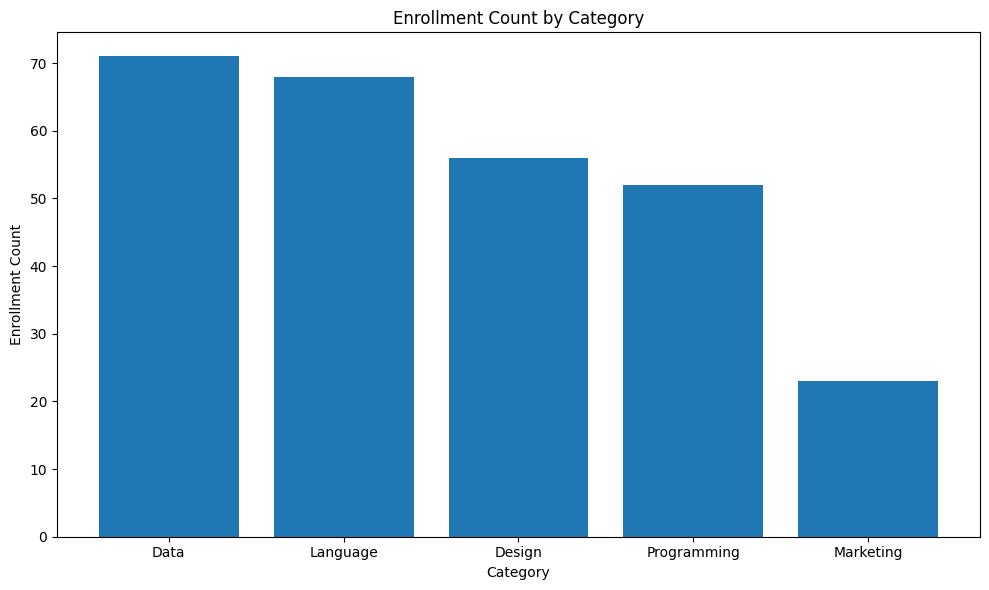

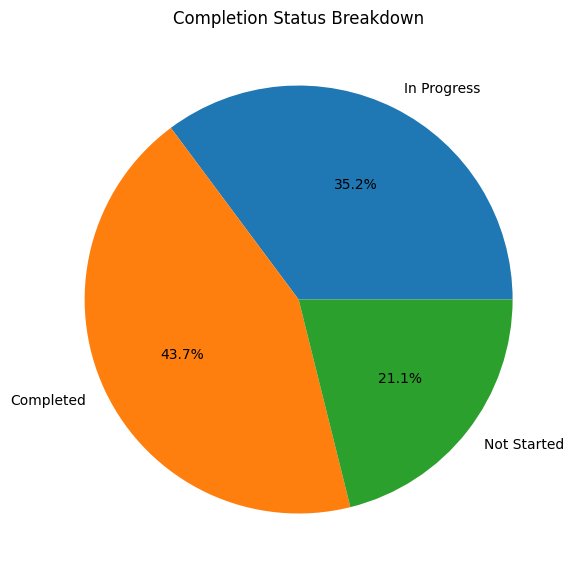

In [60]:
# Visualization
import matplotlib.pyplot as plt
# import seaborn as sns

# Chart 1: Enrollment count by category (bar chart)
# Tip: you can query with duckdb.sql(...).df() and plot the result, or use plain pandas
data = duckdb.sql("SELECT category, COUNT(*) AS enrollment_count FROM df GROUP BY category ORDER BY enrollment_count DESC").df()
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(data['category'], data['enrollment_count'])
ax.set_xlabel('Category')
ax.set_ylabel('Enrollment Count')
ax.set_title('Enrollment Count by Category')
plt.tight_layout()
plt.show()

# Chart 2: Completion status breakdown (pie chart)
data = duckdb.sql("SELECT completion_status, COUNT(*) AS enrollment_count FROM df GROUP BY completion_status").df()
fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(data['enrollment_count'], labels=data['completion_status'], autopct='%1.1f%%')
ax.set_title('Completion Status Breakdown')
plt.tight_layout()
plt.show()


---
# 💼 Business Insights
**What did I discover?**

- Data at 80,000 KRW or more is **50** rows (**about 18%** of 270), all Pandas at **99,000** KRW.
  (8만원 이상 Data는 50건, 약 18%. 전부 Pandas)
- Marketing has the highest avg rating (**4.50**) and the smallest count (**23**). Volume leader is Data (**71**), not Marketing.
  (평점 1등은 Marketing, 건수 1등은 Data. 리더보드가 두 개)
- Completion mix is **44% / 35% / 21%**. Completed is largest but not a majority. Not Started is about half of Completed.
  (완료가 제일 커도 과반이 아님. 미시작은 완료의 약 절반)
 

---
# 🎯 Business Recommendation
**If I were the Business Analyst...**

1. Treat the 80,000 KRW Data list as the Pandas course, not all of Data.
   (8만원 이상 Data 목록은 Data 전체가 아니라 Pandas 과목으로 볼 것)
2. Do not merge rating and volume into one best-category rank. Put students where Data and Language already are (**71**, **68**). Treat Marketing **4.50** as a small-book quality flag, not a budget winner.
   (평점과 건수를 하나의 1등으로 합치지 말 것. 학생 수는 Data·Language. Marketing 4.50은 작은 카테고리의 품질 신호)
3. Split the funnel: **21%** never started vs **35%** in progress. Those are two jobs, not one completion problem.
   (미시작 21%와 진행중 35%를 같은 완료 문제로 묶지 말 것)
 

---
# ❌ Mistakes
**What mistakes did I make today?**

- Counted completed 5-star rows as 45. The query returns **46**.
  (5점 완료를 45로 셈. 쿼리는 46건)
- Read Chart 2 as even slices. Completed **44%** vs Not Started **21%** differ.
  (파이를 비슷한 조각으로 읽음. 44%와 21%는 다름)
- Ranked categories by `AVG(rating)` before looking at `COUNT(*)`.
  (건수 COUNT를 보기 전에 평균 평점으로 순위를 매김)
 

---
# ✅ What I Learned
**Today's biggest lesson**

- `duckdb.sql("SELECT ... FROM df")` runs SQL on a pandas DataFrame. No separate database.
  (duckdb.sql로 df에 SQL. 별도 DB 없음)
- `WHERE` filters rows. `GROUP BY` with `COUNT`/`AVG` is the category table. `LIMIT` cuts rows and is a tie when many ratings are **5.0**.
  (WHERE는 필터. GROUP BY + COUNT/AVG가 카테고리 표. LIMIT는 자르기. 5점 동점이면 순위가 아님)
- A `WHERE` list can be one course. `COUNT(*)` rank and `AVG(rating)` rank can be two different #1s.
  (WHERE 목록이 한 과목일 수 있음. 건수 1등과 평점 1등이 다를 수 있음)
 

---
# 🧠 Reflection

**What was difficult?**
Q2 `LIMIT 10` vs the 5.0 tie, and reading Chart 2 by shape.
(Q2 상위 10개 자를지, 차트 2를 모양으로만 볼지)

**Why?**
The question asks for top 10, but rating is 3/4/5 so completed 5.0 is **46** rows. A pie can look even when **44%** and **21%** are not equal.
(질문은 상위 10개인데 평점이 3/4/5라 5점이 46건. 파이 조각이 비슷해 보여도 44와 21은 다름)

**How did I solve it?**
Dropped `LIMIT` after the 5.0 count. Split Q3 into `COUNT(*)` vs `AVG(rating)`. Read Chart 2 with `autopct` percents.
(5점 건수를 보고 LIMIT를 뺌. Q3는 COUNT와 AVG로 나눔. 파이는 퍼센트를 읽음)

**What would I do differently next time?**
Check ties before `LIMIT`. Read `COUNT(*)` next to `AVG`. Do not call pie slices the same before the percents.
(LIMIT 전에 동점 확인. AVG 옆에 COUNT. 퍼센트 없이 파이 조각을 같다고 말하지 않기)


---
# ⭐ Self Evaluation

**Understanding**  
★★★★★★★☆☆☆  
SELECT/WHERE/GROUP BY worked. LIMIT ties and reading tables needed help.  
(SELECT/WHERE/GROUP BY는 됨. LIMIT 동점과 표 읽기는 도움 필요)

**Confidence**  
★★★★★★☆☆☆☆  

**Difficulty**  
★★★★★★★☆☆☆  
Reading the questions and interpreting the pie chart were harder than the queries.  
(쿼리보다 질문 읽기와 파이 해석이 더 어려웠음)

---
# 📌 Tomorrow
*Tomorrow I will learn:*

- Practice Day 07 — pandas merge / join
  (pandas 테이블 병합 merge/join) 